In [11]:
import os
from ParseEvent import ParseEvent
import pickle
import cv2

def get_video_info(video_path):
    # 打开视频文件
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError("无法打开视频文件，请检查路径是否正确！")
    
    # 获取视频的基本信息
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 总帧数
    fps = cap.get(cv2.CAP_PROP_FPS)  # 帧率
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  # 视频宽度
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))  # 视频高度
    
    # 释放资源
    cap.release()
    
    return {
        "total_frames": total_frames,
        "fps": fps,
        "width": width,
        "height": height,
        "duration": total_frames / fps if fps > 0 else 0  # 计算视频时长（秒）
    }

dir = 'temp' 
def find_evt_files_without_pkl(dir=str):
    evt_files_without_pkl = []
    video_files = []
    for root, dirs, files in os.walk(dir):
        for file in files:
            if file.endswith('.evt'):
                pkl_file_name = os.path.splitext(file)[0] + '.pkl'
                if pkl_file_name not in files:
                    evt_file_path = os.path.join(root, file)
                    evt_files_without_pkl.append(evt_file_path)
            if file.endswith('.mp4'):
                video_file_path = os.path.join(root, file)
                video_files.append(video_file_path)
    
    return evt_files_without_pkl, video_files

evtPaths, videoPaths = find_evt_files_without_pkl(dir)
count=0
Event=None
if(len(evtPaths)==0):
    print('No evt to be processed!\n')
else:
    print('Find '+str(len(evtPaths))+' File(s)!')

Find 1 File(s)!


In [12]:
# You can edit data here
if (count < len(evtPaths)):
    Event=ParseEvent(evtPaths[count])
    print('Processing file '+str(count+1)+'/'+str(len(evtPaths))+': '+evtPaths[count])
    for video in videoPaths:
        print(get_video_info(video))
else:
    print('All Finished!\n')

Processing file 1/1: temp\lyf_185.evt


[]
[]
815756
66


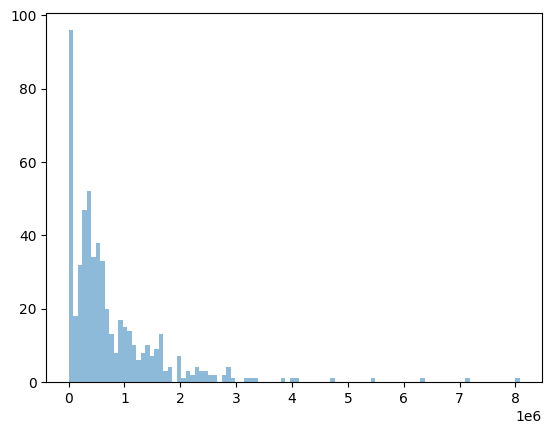

In [4]:
import numpy as np
import matplotlib.pyplot as plt

msStart = Event['MsEnable']['Time_S']
msEnd = Event['MsEnable']['Time_E']
print(msStart)
print(msEnd)
msStart = np.array(Event['MsSync']['Time_E'])
pump = np.array(Event['Pump0']['Time_E'])
msDif = msStart[1:] - msStart[:-1]

bsStart = np.array(Event['BaslerSync']['Time_S'])
print(len(bsStart))

vsStart = np.array(Event['VisualStimulate']['Time_S'])
vsDif = vsStart[1:] - vsStart[:-1]
# print(len(vsStart[(vsDif < 1000) & (vsDif > 500)]))
print(len(vsDif[vsDif < 2 * 500]))
# fig = plt.figure(figsize=(20, 3), dpi=500)
# axe = fig.add_subplot(111)

# plt.scatter(vsStart, np.zeros_like(vsStart), marker='o', s=10, c='r')
plt.hist(vsDif, bins=100, alpha=0.5, label='VisualStimulate')
# axe.scatter(pump, np.ones_like(pump), marker='o', s=10, c='b')
plt.show()
for i, t in enumerate(Event['MsEnable']['Time_S']):
    end = msEnd[i] + 10000
    tempSyncS = np.array(Event['MsSync']['Time_S'])
    tempSyncE = np.array(Event['MsSync']['Time_E'])
    print(f'chunk{i}')
    print(len(np.where((tempSyncS > t) & (tempSyncS < end))[0]))
    print(len(np.where((tempSyncE > t) & (tempSyncE < end))[0]))


In [14]:
if (Event != None):
    # pkl_path=os.path.splitext(evtPaths[count])[0] + '.pkl'
    pkl_path='logeventpkl/' + os.path.splitext(evtPaths[count])[0].split('\\')[-1] + '.pkl'
    with open(pkl_path,"wb") as pkl_f:
        pickle.dump(Event,pkl_f)
        Event=None
    print('File Saved!\n')

File Saved!

